In [1]:
# heatmap 상관계수 매트릭스 시각화
# pairplot으로 전체 변수 관계 한눈에 파악
# 다변량 패턴 발견 및 변수 선택
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [4]:
iris = sns.load_dataset('iris')
iris['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [9]:
# 어떤 값들이 서로 연결되어 있나?
numeric_cols = iris.describe().columns
corr_matrix = iris[numeric_cols].corr()
corr_matrix.round(3)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


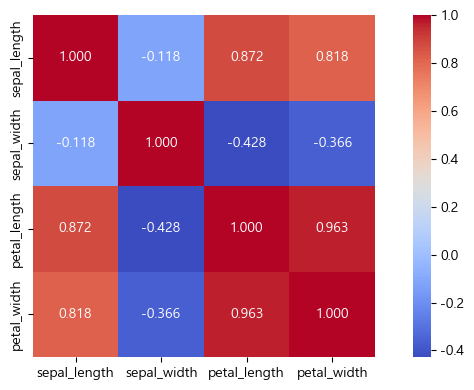

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(data=corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', ax=ax, square=True)
# labels = ['꽃받침길이', '꽃받침너비', '꽃잎길이', '꽃입너비']
# ax.set_xticklabels(labels)
# ax.set_yticklabels(labels)
plt.tight_layout()
plt.show()

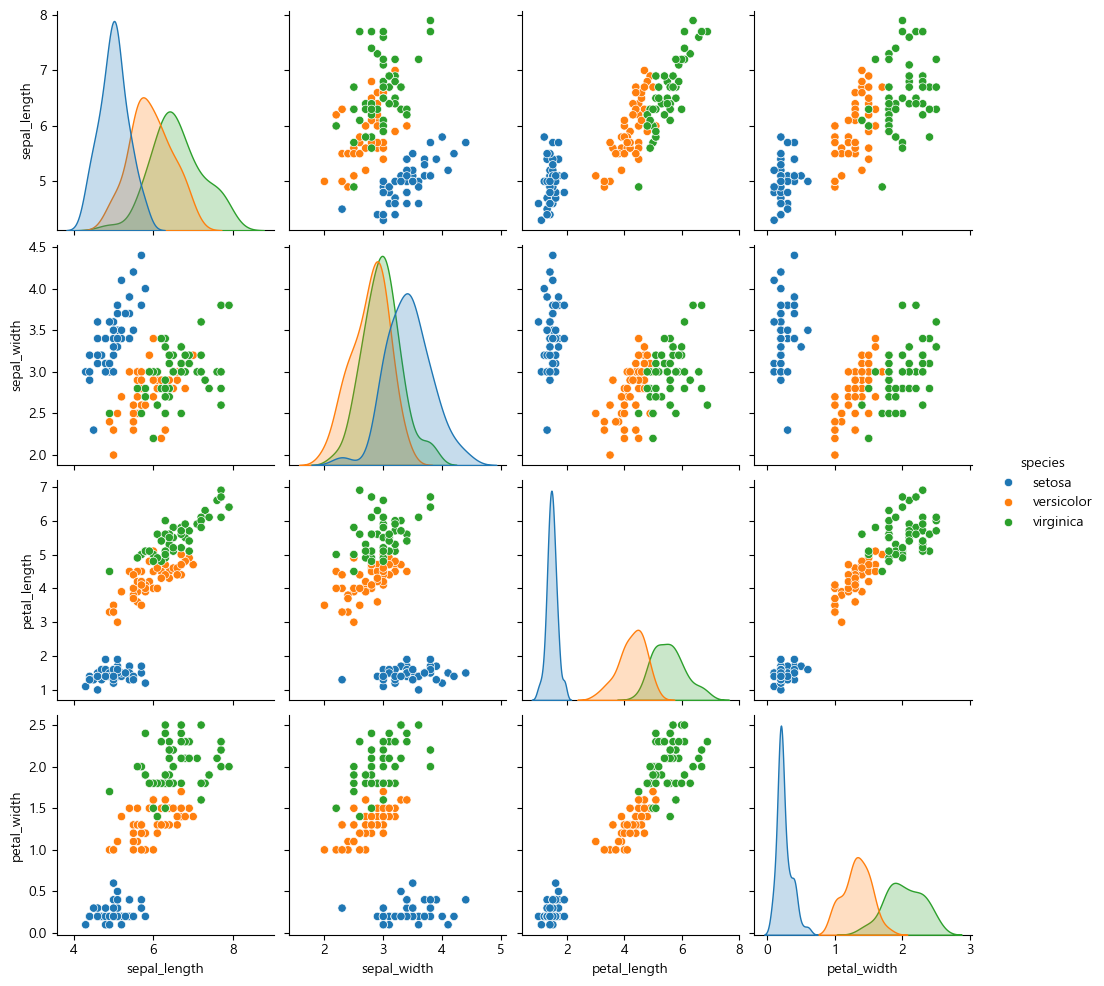

In [21]:
# 모든 조합을 시각화 pairplot
sns.pairplot(iris, hue='species')

In [ ]:
# 자동차 데이터 heatmap
# 연비 향상 요인 분석
# 1. 연비에 영향을 주는 변수들 (상관관계 강한(양수,음수))
# 2. 연비에 영향을 주는 변수들끼리의 상관관계 - 다중공선성 문제 (서로 0.9이상 상관)
#  연비와 약한 양의 상관관계 => 독립적인 정보

mpg = sns.load_dataset('mpg')
numeric_cols = mpg.describe().columns
corr_mpg = mpg[numeric_cols].corr()
corr_mpg



,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289,0.579267
cylinders,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419,-0.348746
displacement,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684,-0.370164
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361
weight,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457,-0.306564
acceleration,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000,0.288137
model_year,0.579267,-0.348746,-0.370164,-0.416361,-0.306564,0.288137,1.000000


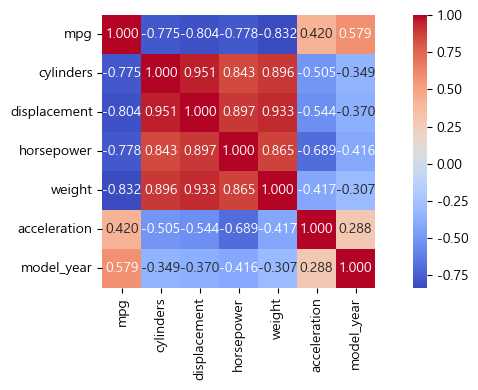

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(data=corr_mpg, annot=True, fmt='.3f', cmap='coolwarm', ax=ax, square=True)
plt.tight_layout()
plt.show()

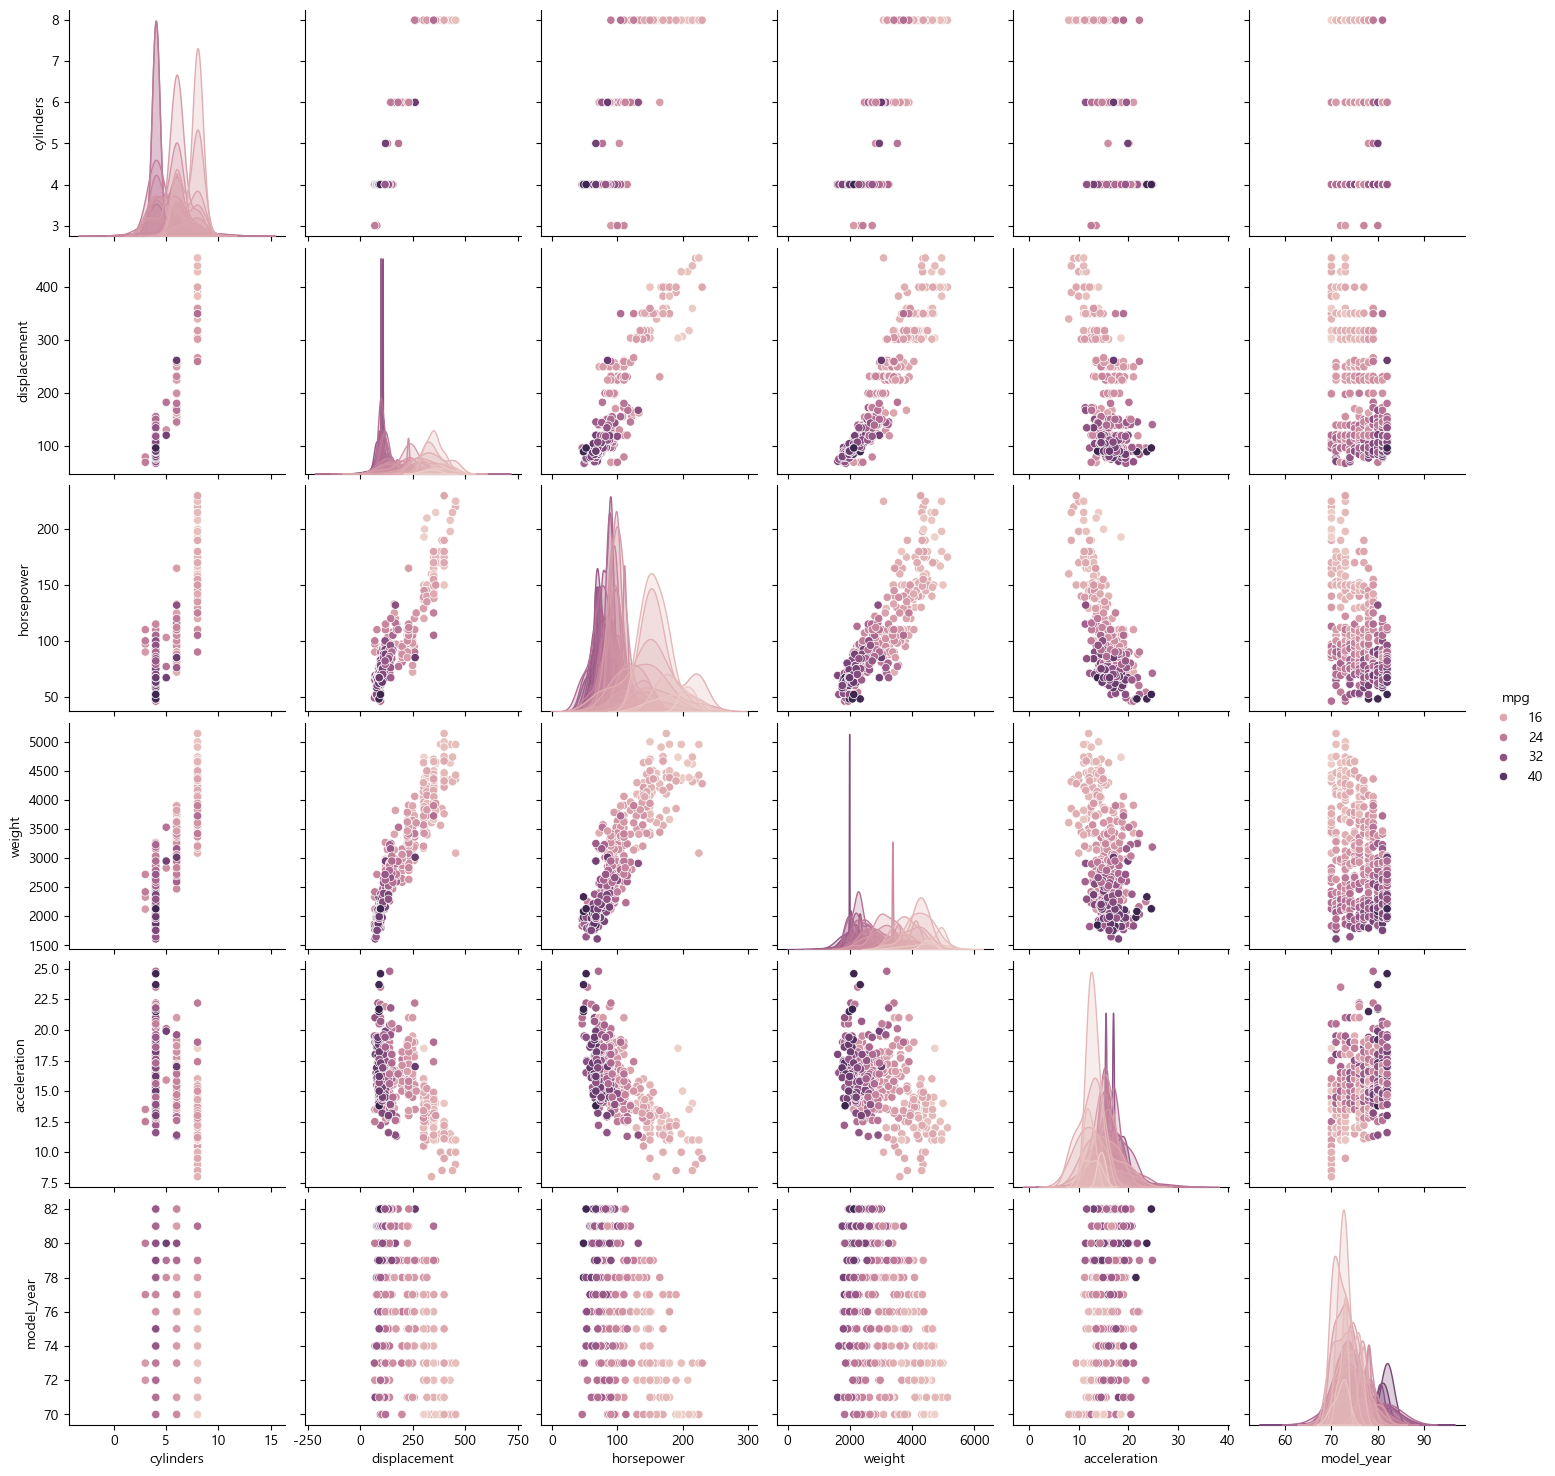

In [ ]:
# 모든 조합을 시각화 pairplot
sns.pairplot(mpg, hue='mpg')

mpg[numeric_cols].drop(columns=[''])

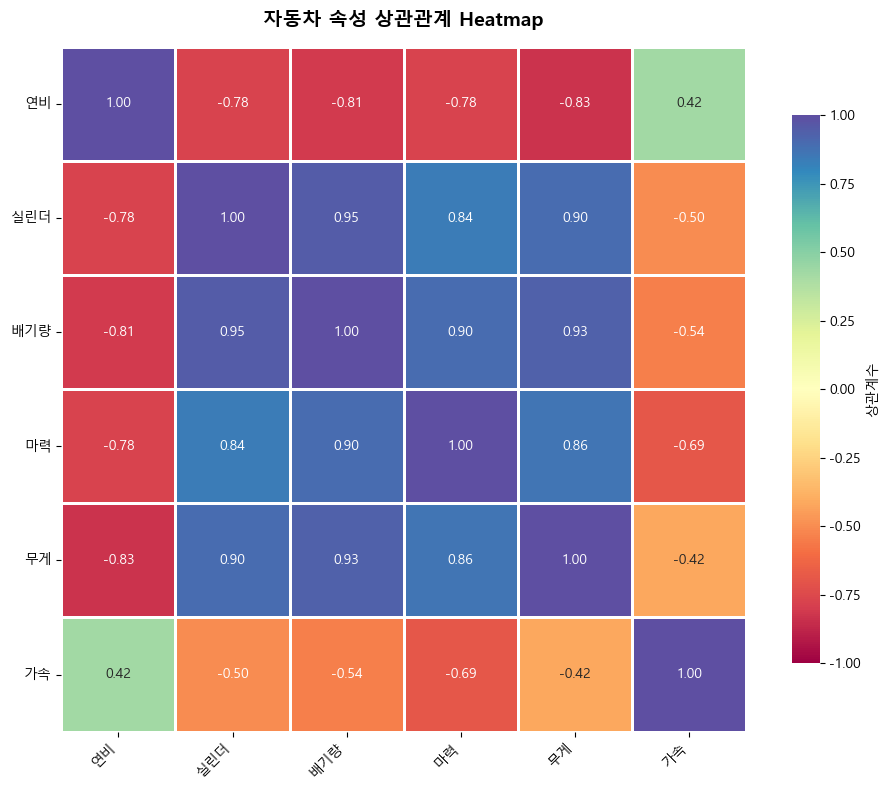


연비(mpg)와의 상관계수:
mpg             1.000000
acceleration    0.423329
cylinders      -0.777618
horsepower     -0.778427
displacement   -0.805127
weight         -0.832244
Name: mpg, dtype: float64


In [32]:
# MPG 데이터 로드
mpg = sns.load_dataset('mpg')

# 수치형 변수만 선택
mpg_numeric = mpg[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']].dropna()
mpg_corr = mpg_numeric.corr()

fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap 생성
sns.heatmap(mpg_corr, annot=True, fmt='.2f', cmap='Spectral',
            center=0, square=True, linewidths=2, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': '상관계수'},
            ax=ax, vmin=-1, vmax=1)

ax.set_title('자동차 속성 상관관계 Heatmap', fontsize=14, fontweight='bold', pad=15)

# 레이블 한글화
mpg_labels = ['연비', '실린더', '배기량', '마력', '무게', '가속']
ax.set_xticklabels(mpg_labels, rotation=45, ha='right')
ax.set_yticklabels(mpg_labels, rotation=0)

plt.tight_layout()
plt.show()

# 강한 상관관계 추출
print("\n연비(mpg)와의 상관계수:")
print(mpg_corr['mpg'].sort_values(ascending=False))

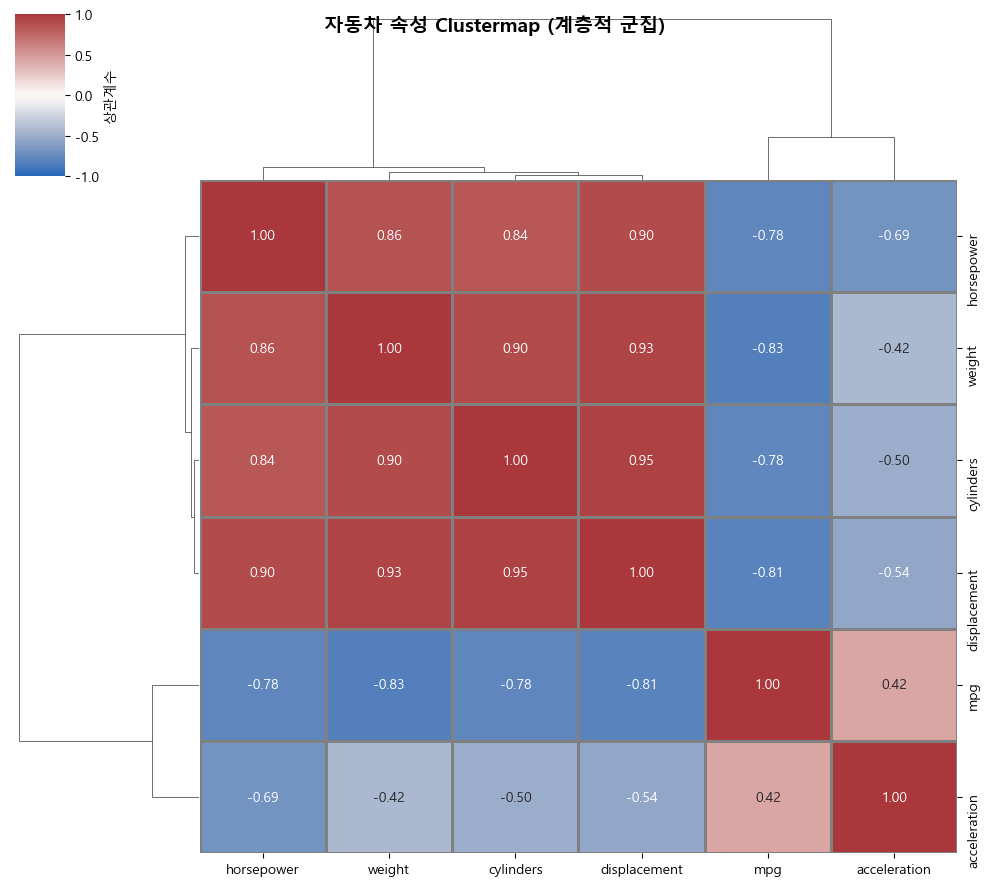

In [34]:
# 계층적 군집화 : ClusterMap

g = sns.clustermap(mpg_corr, annot=True, fmt='.2f', cmap='vlag',
                   center=0, linewidths=1, linecolor='gray',
                   cbar_kws={'label': '상관계수'},
                   figsize=(10, 9), vmin=-1, vmax=1)

g.fig.suptitle('자동차 속성 Clustermap (계층적 군집)', fontsize=14, fontweight='bold', y=0.98)

plt.show()